In [13]:
import torch
import math
import numpy as np 
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F

from src.gpt.model import GPT2
from src.gpt.tokenizer import BPETokenizer

In [21]:
device      = "cuda" if torch.cuda.is_available() else "cpu"
data_path   = "data/FineWebEdu/data.bin"
merges_path = "data/FineWebEdu/merges.txt"
save_path   = "models/FineWebEdu.pt"

In [22]:
tokenizer = BPETokenizer(
     special_tokens={"<|endoftext|>": 8000}
).load(merges_path)


In [23]:
data = np.memmap(data_path,dtype=np.uint16, mode="r")
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

In [24]:
tokenizer.show_merges()

256: ' ' + 't' -> ' t'
257: ' ' + 'a' -> ' a'
258: 'h' + 'e' -> 'he'
259: 'i' + 'n' -> 'in'
260: 'r' + 'e' -> 're'
261: ' t' + 'he' -> ' the'
262: 'o' + 'n' -> 'on'
263: 'e' + 'r' -> 'er'
264: ' ' + 'o' -> ' o'
265: 'a' + 't' -> 'at'
266: ' ' + 's' -> ' s'
267: 'e' + 'n' -> 'en'
268: ' ' + 'c' -> ' c'
269: 'e' + 's' -> 'es'
270: ' ' + 'w' -> ' w'
271: 'i' + 's' -> 'is'
272: 'n' + 'd' -> 'nd'
273: 'o' + 'r' -> 'or'
274: 'i' + 't' -> 'it'
275: ' ' + 'p' -> ' p'
276: 'a' + 'l' -> 'al'
277: 'e' + 'd' -> 'ed'
278: ' o' + 'f' -> ' of'
279: ' ' + 'b' -> ' b'
280: ' ' + 'f' -> ' f'
281: 'a' + 'n' -> 'an'
282: ' ' + 'in' -> ' in'
283: 'a' + 'r' -> 'ar'
284: 'in' + 'g' -> 'ing'
285: 'o' + 'u' -> 'ou'
286: ' ' + 'm' -> ' m'
287: 'i' + 'c' -> 'ic'
288: ' a' + 'nd' -> ' and'
289: ' t' + 'o' -> ' to'
290: 'i' + 'on' -> 'ion'
291: ' ' + 'd' -> ' d'
292: 'r' + 'o' -> 'ro'
293: 'l' + 'e' -> 'le'
294: 'a' + 's' -> 'as'
295: ' ' + 'h' -> ' h'
296: 'en' + 't' -> 'ent'
297: ' t' + 'h' -> ' th'
298: 'c' + '

In [25]:
tokenizer.special_tokens

{'<|endoftext|>': 8000}

In [26]:
train_data[:100]

memmap([4877,   46, 2616,   59, 7557,  458, 2792,  920,   49,   10,   67,
        4073, 1430,  289, 5916,  288, 2972,  257,  359, 5141, 3668,  278,
         447, 2913,   46,   10,   80, 7479,  350, 1636,  261,  729,  289,
        5456,  331,  493,  733,  520,  257, 1694,  352, 4200,  460,  351,
        2527,   46,  548,  377,   44,  261, 3615,  289, 5481, 4250,  822,
         432,  308, 1945,  288, 1460,  830,  327,  257, 1973,   46,  363,
         729, 2176,  309,  289,  314, 1387, 2072,  289, 2659,  289,  261,
         733,   46, 1054, 3734,  382, 1600, 2659,  589, 7106,  432, 1130,
         822,   46,  359, 7479,  593, 4162,  289, 5069,  352,  261,  733,
         442], dtype=uint16)

In [38]:
### Config
vocab_size = len(tokenizer.vocab)
batch_size = 32
n_embed    = 320
n_head     = 8
n_layer    = 6
block_size = 256
dropout    = 0.2
eval_iters = 30


In [39]:
def get_batch(data, block_size, batch_size, device):
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i   : i+block_size].astype(np.int64))   for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1 : i+1+block_size].astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

In [40]:
@torch.no_grad()
def estimate_loss(model):
    model.eval()
    splits = {"train": train_data, "val": val_data}
    out = {}
    for split, data in splits.items():
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            xb, yb = get_batch(data, block_size, batch_size, device)
            _, loss = model(xb, yb)
            losses[k] = loss
        out[split] = losses.mean().item()
    model.train()
    return out 

In [41]:
model = GPT2(
    vocab_size,
    n_embed,
    n_head,
    n_layer,
    block_size,
    dropout
).to(device)

params_count = sum([p.numel() for p in model.parameters()])
print(f"{params_count/1e6:.2f}M Parameters")

12.59M Parameters


In [42]:
# Initializing the Optimizer and Context Manager

max_steps = 40000
eval_interval = 500


max_lr = 1e-3
min_lr = 1e-4
warmup_steps = max_steps // 20 # 5% of max_steps

optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr)
ctx = torch.autocast(device, dtype=torch.bfloat16)


def get_lr(step):
    if step < warmup_steps: # Linear warmup
        return max_lr * (step+1) / warmup_steps
    ratio = (step - warmup_steps) / (max_steps - warmup_steps) # [0 - 1.0]
    # 1/2 * (1 + cos(pi*ratio)) -> [1, 0]
    coeff = 0.5 * (1.0 + math.cos(math.pi * ratio))
    return min_lr + coeff * (max_lr - min_lr)



In [ ]:
history = {"step": [], "train": [], "val": [], "lr": []}


pbar = tqdm(range(max_steps), desc="GPT2 training", unit="steps")

for step in pbar:

    lr = get_lr(step)
    for group in optimizer.param_groups:
        group["lr"] = lr

    if step % eval_interval == 0 or step == max_steps - 1:
        losses = estimate_loss(model)
        # Logging
        history["step"].append(step)
        history["train"].append(losses["train"])
        history["val"].append(losses["val"])
        history["lr"].append(lr)

        pbar.set_postfix({
            "Train": f"{losses['train']:.4f}", 
            "val"  : f"{losses['val']:.4f}",
            "lr"   : f"{lr:.2e}"
        })

    xb, yb = get_batch(train_data, block_size, batch_size, device)

    with ctx:
        logits, loss = model(xb, yb)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

GPT2 training: 100%|██████████| 3000/3000 [07:33<00:00,  6.61steps/s, Train=2.4506, val=2.5893, lr=1.00e-04] 


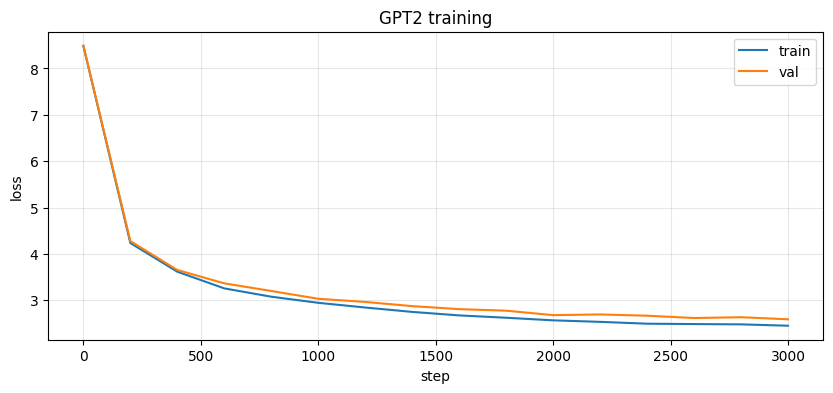

In [32]:
plt.figure(figsize=(10, 4))
plt.plot(history["step"], history["train"], label="train")
plt.plot(history["step"], history["val"], label="val")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("GPT2 training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
@torch.no_grad()
def generate(model, idx, block_size, eot_id, max_new_tokens=5000):
    model.eval()
    for _ in range(max_new_tokens):          # safety ceiling, not the real stop
        idx_cond = idx[:, -block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, idx_next], dim=1)
        if (idx_next == eot_id).all():        # primary stop
            break
    return idx


@torch.no_grad()
def generate_text(model, tokenizer, prompt, block_size, device, max_new_tokens=1000):
    model.eval()
    eot_id = tokenizer.special_tokens["<|endoftext|>"]
    ids = tokenizer.encode(prompt)
    idx = torch.tensor([ids], dtype=torch.long, device=device)
    out = generate(model, idx, block_size, eot_id, max_new_tokens)

    out_ids = out[0].tolist()
    if out_ids and out_ids[-1] == eot_id:
        out_ids = out_ids[:-1]
    return tokenizer.decode(out_ids)


In [37]:
eot_id = tokenizer.special_tokens["<|endoftext|>"]
ids = [eot_id] + tokenizer.encode("Ben was walking down the forest one day")
idx = torch.tensor([ids], dtype=torch.long, device=device)  # (1, 1)
out = generate(model, idx, block_size, eot_id)
print(tokenizer.decode(out[0].tolist()))

<|endoftext|>Ben was walking down the forest one day, he saw a big man sitting on a long tree. He had a bird. It was a big mess. He wanted to go home too early and wait.
"Help!" Ben said. "I like you. It is a toy. It is from the mailman. Shareals, wait for warning."
He swam back to the park. He was very happy. He hugged Ben and said, "Thank you, parrot. You found my toy. He was very responsing, and you go down. You have to rest for a while."
But Ben did not want something to stick. He quits and pushed as he could. He was scared and hurt. He cried and dropped his his cat. He shouted, "Ow! The cat is mean. You are teas. Go away to me."
Ben ran away. He dropped the coin from Lily. He kicked the ladder away. They ran away. They had no fun. They fell with many things.
<|endoftext|>


In [38]:
checkpoint = {
    "model_state": model.state_dict(),
    "config": {                
        "vocab_size": vocab_size,
        "block_size": block_size,
        "n_layer": n_layer,
        "n_head":  n_head,
        "n_embed":  n_embed,
        "dropout": dropout,
    },
    "dataset":     "TinyStories",
}
torch.save(checkpoint, save_path)
